# CMNIST offline empirical-base study

This notebook loads the completed offline run, presents the independent and OT results, and reconstructs the fixed observational empirical bases for post-training checkpoint inference.

The run uses one fixed set of 20,000 independently generated observational rows (not paired colors), batch size 128, Gaussian base noise with standard deviation 0.1, and 100,000 updates for the nuisance and each target flow. The target plug-in reservoir is refreshed every 10,000 completed updates.


In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision.utils import make_grid

_here = Path.cwd().resolve()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "deconfoundingfm").exists())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from deconfoundingfm.experimental import (
    load_cmnist_correction_checkpoint,
    load_result_bundle,
)

RESULT_DIR = Path(os.environ.get(
    "CMNIST_OFFLINE_RESULT_DIR",
    REPO_ROOT / "examples" / "cmnist" / "results" / "offline",
)).resolve()
bundle = load_result_bundle(RESULT_DIR)
config = bundle["config"]
print("Result directory:", RESULT_DIR)
print("Evaluation samples per arm:", config["eval_n"])
print(
    "Study:", config["study_mode"],
    "| observations:", config["observational_n"], config["observational_design"],
    "| batch:", config["batch_size"],
    "| nuisance/target updates:", config["nuisance_steps"], config["target_steps"],
    "| base noise std:", config["base_noise_std"],
    "| reservoir refresh:", config["plugin_reservoir_update_frequency"],
)
print("Saved bundle keys:", sorted(bundle))


Result directory: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/offline
Evaluation samples per arm: 5000
Study: offline_empirical | observations: 20000 iid_observational | batch: 128 | nuisance/target updates: 100000 100000 | base noise std: 0.1 | reservoir refresh: 10000
Saved bundle keys: ['color_diagnostics', 'color_values', 'config', 'convergence', 'data_manifest', 'manifest', 'metrics', 'model_manifest', 'path', 'samples', 'trajectories', 'trajectory_summary']


## Final sliced-Wasserstein metrics

SW2 is computed separately for each treatment arm and then averaged. Every method uses the same random projection directions.


In [2]:
metrics = bundle["metrics"]
rows = [
    {"method": method, "SW2": metrics[f"{method}_sw2"]}
    for method in ("source", "decfm", "ot")
]
display(pd.DataFrame(rows))
print(
    "n per arm:", metrics["evaluation_n_per_arm"],
    "| SW2 projections:", metrics["sw2_projections"],
)


,method,SW2
0,source,0.031793
1,decfm,0.015057
2,ot,0.009991


n per arm: 5000 | SW2 projections: 256


## Generated samples

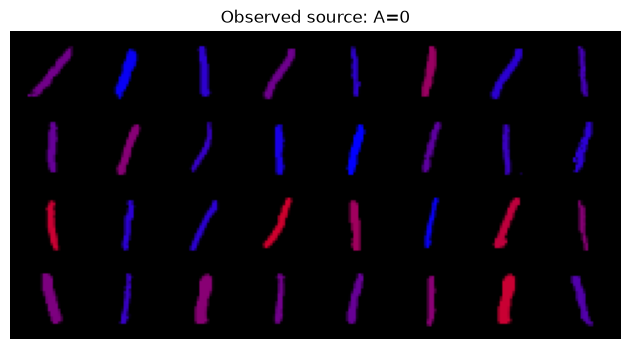

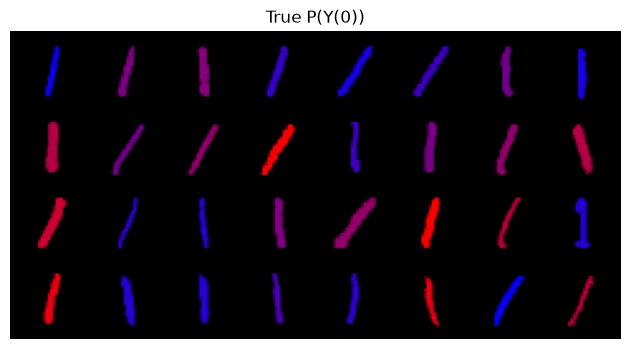

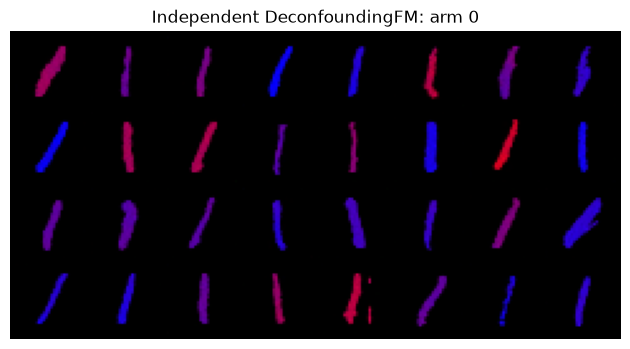

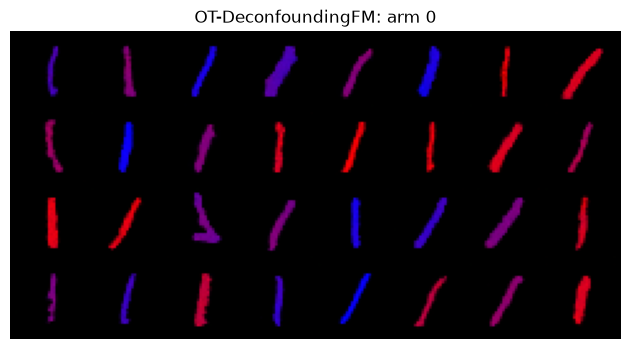

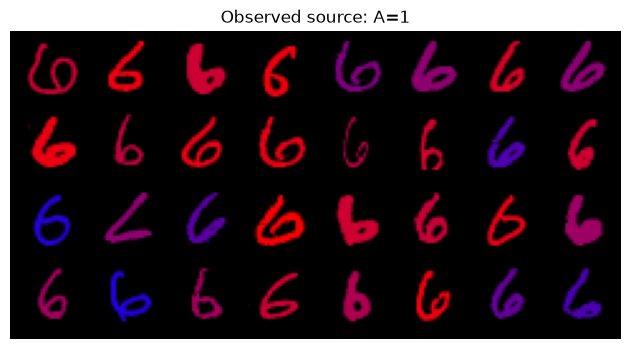

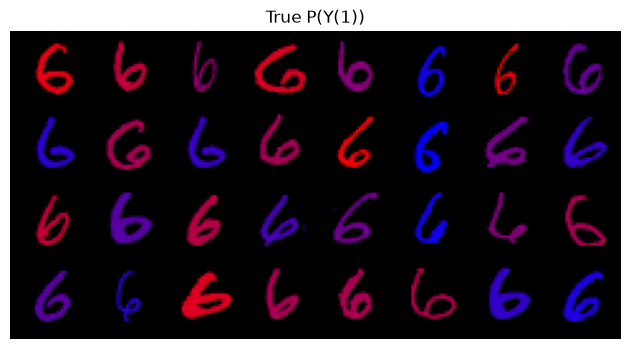

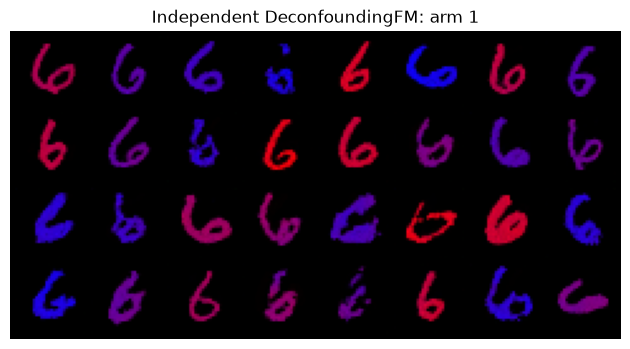

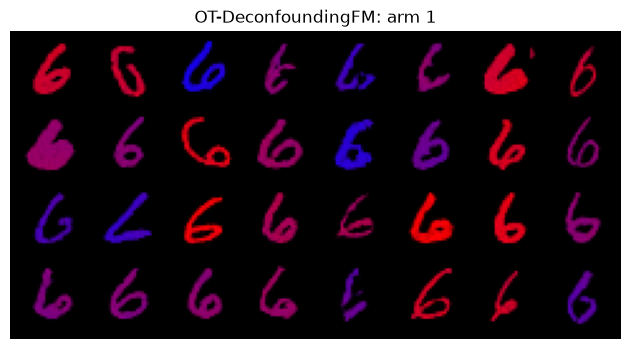

In [3]:
samples = bundle["samples"]

def show_grid(images, title, n=32, nrow=8):
    grid = make_grid(images[:n].clamp(0, 1), nrow=nrow).permute(1, 2, 0).cpu()
    plt.figure(figsize=(8, 4))
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()

for key, title in (
    ("observed_a0", "Observed source: A=0"),
    ("true_a0", "True P(Y(0))"),
    ("decfm_a0", "Independent DeconfoundingFM: arm 0"),
    ("ot_a0", "OT-DeconfoundingFM: arm 0"),
    ("observed_a1", "Observed source: A=1"),
    ("true_a1", "True P(Y(1))"),
    ("decfm_a1", "Independent DeconfoundingFM: arm 1"),
    ("ot_a1", "OT-DeconfoundingFM: arm 1"),
):
    show_grid(samples[key], title)


## SW2 convergence by saved checkpoint

Every point uses the same deterministic 512-image truth set and the same noised fixed empirical-base batch in each arm, as well as common projection directions. Differences across steps therefore reflect the saved correction weights rather than new empirical resamples or noise draws.


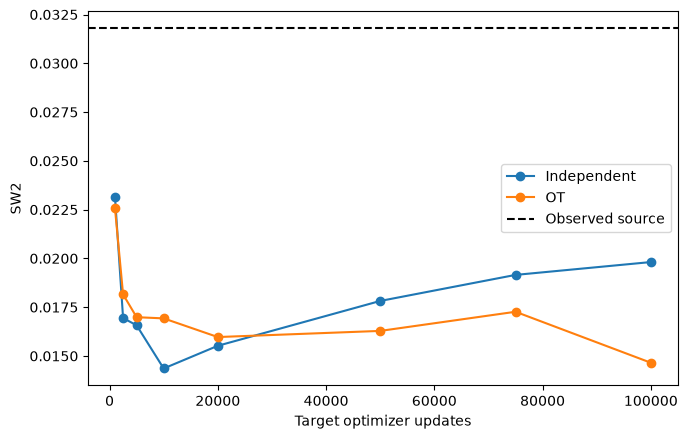

In [4]:
convergence = bundle["convergence"]
plt.figure(figsize=(7, 4.5))
plt.plot(convergence["steps"], convergence["decfm"], marker="o", label="Independent")
plt.plot(convergence["steps"], convergence["ot"], marker="o", label="OT")
plt.axhline(metrics["source_sw2"], linestyle="--", color="black", label="Observed source")
plt.xlabel("Target optimizer updates")
plt.ylabel("SW2")
plt.legend()
plt.tight_layout()
plt.show()


## Learned color distributions \(P(X(a))\)

For each generated image, color is recovered as total foreground red mass divided by total foreground red-plus-blue mass, matching the paper's \(R/(R+B)\) transformation. The causal target is uniform for both arms.


In [5]:
color_diag = bundle["color_diagnostics"]
color_rows = [
    {"method": method, **values}
    for method, values in color_diag.items()
]
display(pd.DataFrame(color_rows))


,method,arm0_vs_arm1_w1,arm0_vs_uniform_w1,arm1_vs_uniform_w1,arm0_vs_uniform_ks,arm1_vs_uniform_ks,n_images_arm0,n_images_arm1
0,source,0.325208,0.163057,0.162150,0.262431,0.252573,5000,5000
1,truth,0.007183,0.006010,0.002561,0.018066,0.007896,5000,5000
2,decfm,0.093296,0.104102,0.032442,0.168522,0.058492,5000,5000
3,ot,0.057037,0.008201,0.052277,0.024276,0.074556,5000,5000


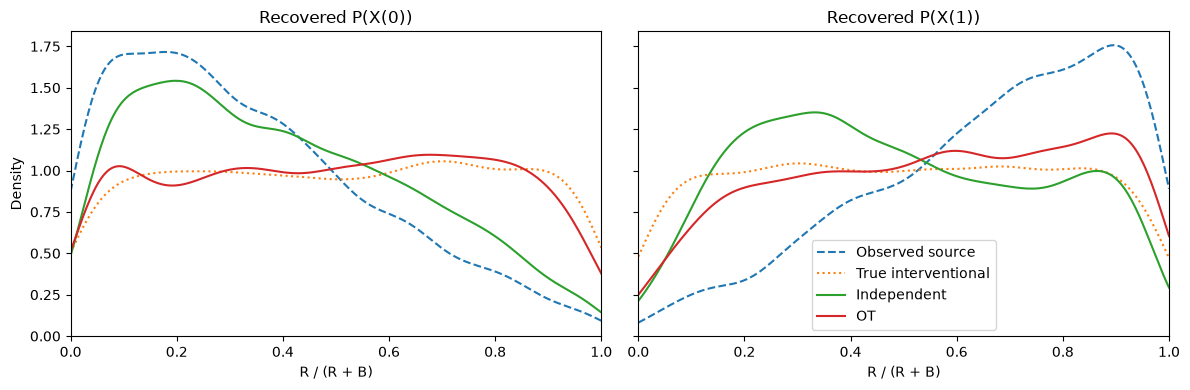

In [6]:
color_values = bundle["color_values"]

def kde(values, grid):
    values = values[torch.isfinite(values)].float()
    bandwidth = max(1.06 * float(values.std(unbiased=False)) * len(values) ** (-0.2), 0.015)
    z = (grid[:, None] - values[None, :]) / bandwidth
    density = torch.exp(-0.5 * z.square()).mean(dim=1) / (bandwidth * (2 * torch.pi) ** 0.5)
    return density

grid = torch.linspace(0, 1, 300)
styles = {
    "source": {"label": "Observed source", "linestyle": "--"},
    "truth": {"label": "True interventional", "linestyle": ":"},
    "decfm": {"label": "Independent", "linestyle": "-"},
    "ot": {"label": "OT", "linestyle": "-"},
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for arm, ax in enumerate(axes):
    for method, style in styles.items():
        values = color_values[method][f"arm{arm}"]
        ax.plot(grid, kde(values, grid), **style)
    ax.set_title(f"Recovered P(X({arm}))")
    ax.set_xlabel("R / (R + B)")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("Density")
axes[1].legend()
plt.tight_layout()
plt.show()


## Flow-change and path diagnostics

A shared resample of 512 images from the fixed observational arm pools receives Gaussian base noise and is transformed by both methods. Endpoint change is measured only over foreground pixels identified from the corresponding clean source digit, so background noise does not define the mask. Full trajectories are retained for the top- and bottom-changing examples.


In [7]:
trajectory_summary = bundle["trajectory_summary"]
rows = []
for method in ("decfm", "ot"):
    rows.append({"method": method, **trajectory_summary[method]["average_over_arms"]})
display(pd.DataFrame(rows))


,method,mean_foreground_pixel_change,mean_path_length,mean_endpoint_displacement,mean_straightness_ratio,mean_bar_E_v,mean_bar_E_vdot,dimension,n_trajectories_per_arm
0,decfm,0.112452,0.157544,0.116505,1.420486,0.026258,1.214231,2352,512
1,ot,0.123783,0.132288,0.114499,1.176673,0.018119,0.432928,2352,512


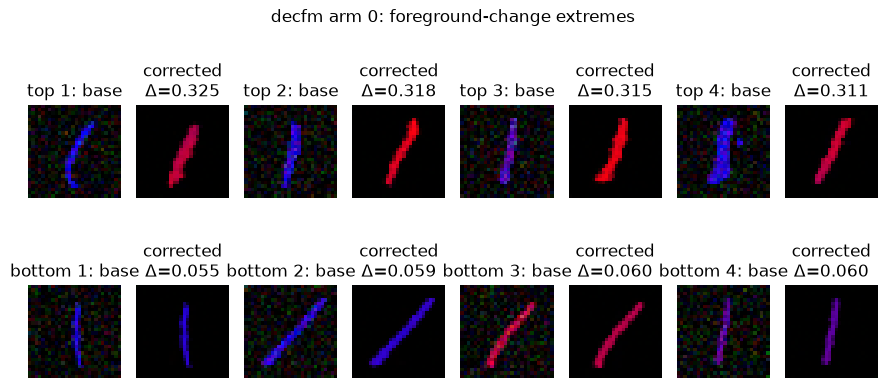

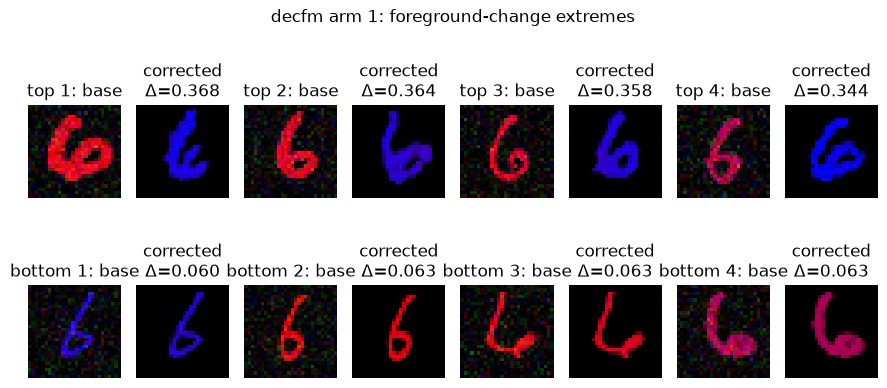

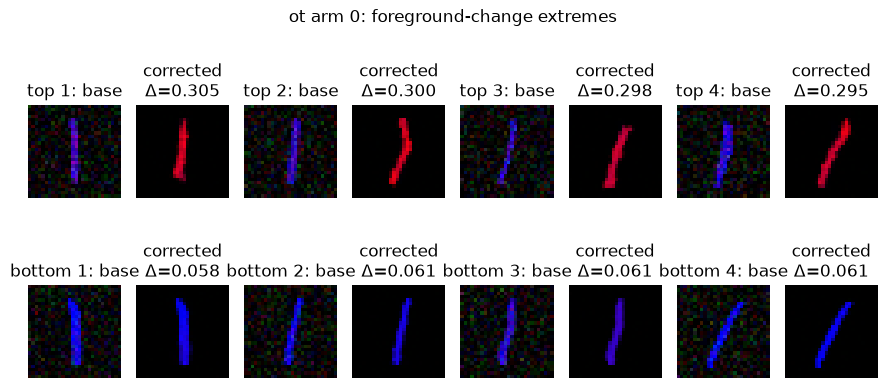

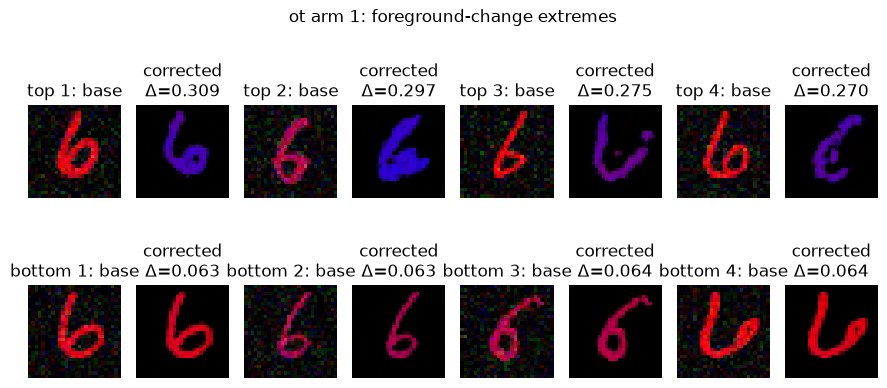

In [8]:
trajectories = bundle["trajectories"]

def show_change_extremes(method, arm, keep=4):
    record = trajectories[method][f"arm{arm}"]
    fig, axes = plt.subplots(2, 2 * keep, figsize=(2.2 * keep, 4.5))
    for row, extreme in enumerate(("top", "bottom")):
        selected = record[extreme]
        sequence = selected["trajectory"]
        scores = selected["foreground_pixel_change"]
        for j in range(min(keep, sequence.shape[1])):
            axes[row, 2*j].imshow(sequence[0, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j].set_title(f"{extreme} {j+1}: base")
            axes[row, 2*j+1].imshow(sequence[-1, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j+1].set_title(f"corrected\nΔ={scores[j]:.3f}")
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(f"{method} arm {arm}: foreground-change extremes")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    for arm in (0, 1):
        show_change_extremes(method, arm)


## Selected full trajectories

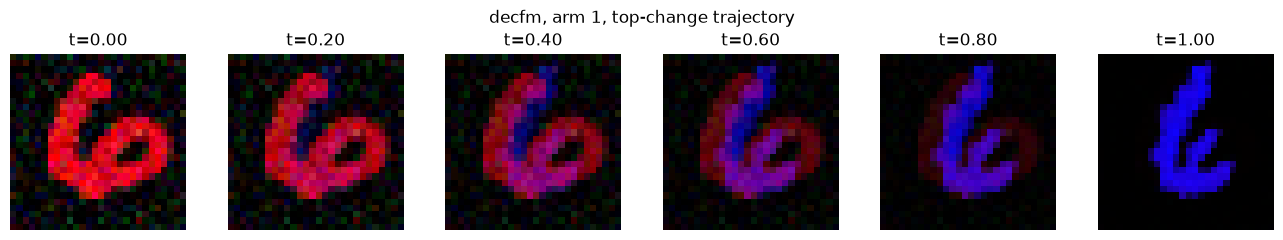

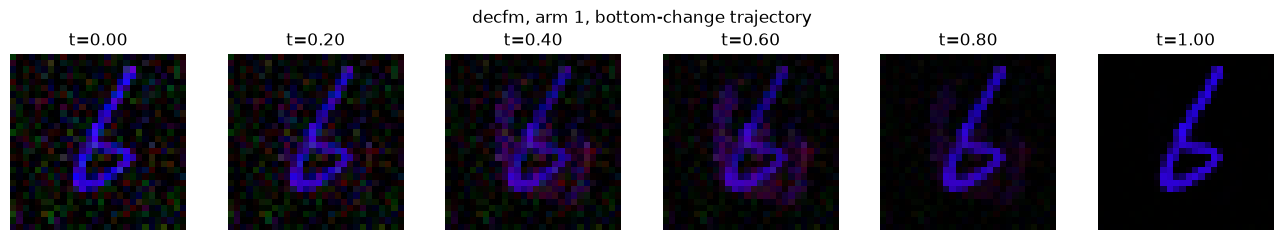

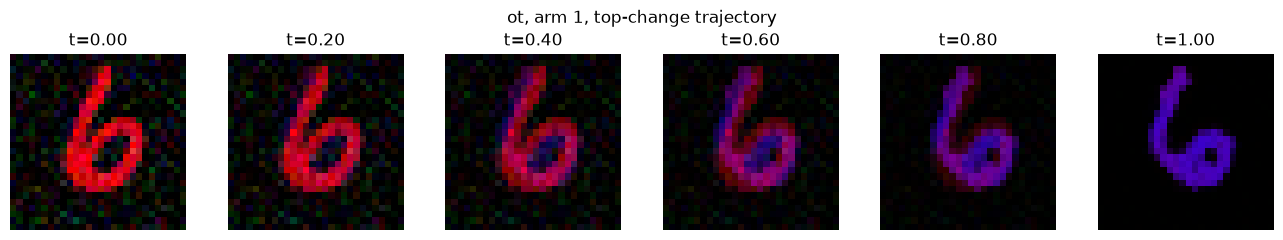

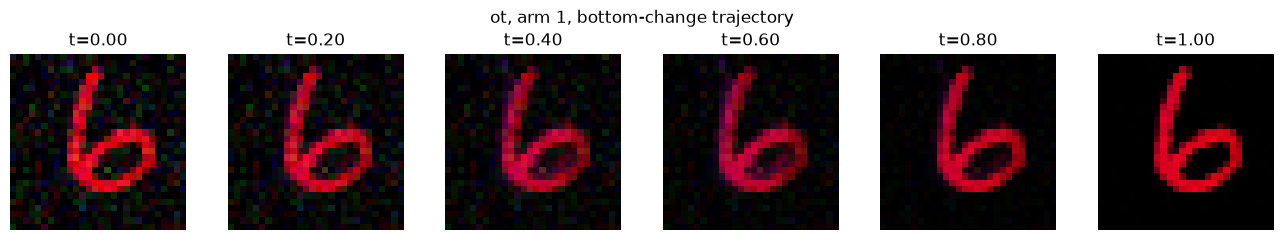

In [9]:
def show_saved_trajectory(method, arm, extreme="top", rank=0, frames=6):
    sequence = trajectories[method][f"arm{arm}"][extreme]["trajectory"][:, rank]
    indices = torch.linspace(0, len(sequence) - 1, frames).long()
    fig, axes = plt.subplots(1, frames, figsize=(2.2 * frames, 2.4))
    for ax, index in zip(axes, indices):
        ax.imshow(sequence[index].permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"t={index.item()/(len(sequence)-1):.2f}")
        ax.axis("off")
    fig.suptitle(f"{method}, arm {arm}, {extreme}-change trajectory")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    show_saved_trajectory(method, arm=1, extreme="top")
    show_saved_trajectory(method, arm=1, extreme="bottom")


## Fresh inference from a saved checkpoint

This cell reconstructs the fixed iid observational population, its arm-stratified empirical bases, configured Gaussian base noise, and the correction velocity from the portable manifest. It does not load nuisance models, propensity fits, plug-in reservoirs, or cached base samples.


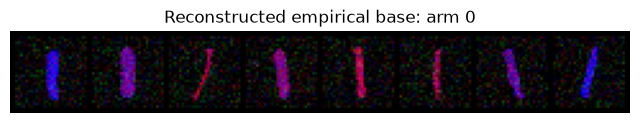

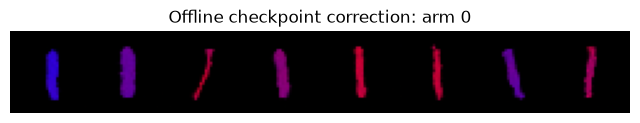

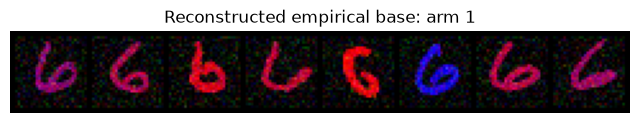

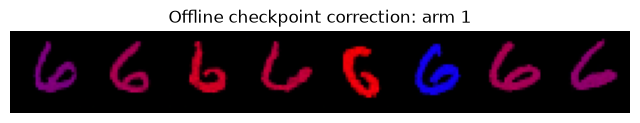

Loaded examples/cmnist/results/offline/models/ot/step_100000.pt on cuda


In [10]:
model_manifest = bundle["model_manifest"]
INFERENCE_METHOD = "ot"
model_entry = model_manifest["models"][INFERENCE_METHOD]
INFERENCE_STEP = str(model_entry["final_step"])
checkpoint_path = RESULT_DIR / model_entry["checkpoints"][INFERENCE_STEP]
INFERENCE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sampler = load_cmnist_correction_checkpoint(checkpoint_path, device=INFERENCE_DEVICE)
torch.manual_seed(config["seed"] + 9000)
fresh = {}
for arm in (0, 1):
    y0, y1 = sampler.sample(arm, 8, return_base=True)
    fresh[arm] = {"base": y0.cpu(), "corrected": y1.cpu()}
    show_grid(y0.cpu(), f"Reconstructed empirical base: arm {arm}", n=8)
    show_grid(y1.cpu(), f"Offline checkpoint correction: arm {arm}", n=8)
print("Loaded", checkpoint_path.relative_to(REPO_ROOT), "on", INFERENCE_DEVICE)


In [11]:
# New trajectories can be generated from reconstructed empirical or user-supplied bases.
fresh_trajectory, fresh_midpoint_velocities = sampler.trajectory(
    arm=1, y0=fresh[1]["base"][:2].to(INFERENCE_DEVICE)
)
print("trajectory shape:", tuple(fresh_trajectory.shape))
print("midpoint velocity shape:", tuple(fresh_midpoint_velocities.shape))


trajectory shape: (51, 2, 3, 28, 28)
midpoint velocity shape: (50, 2, 3, 28, 28)


## Reconstructing the observational population

The exact fixed population of 20,000 independently generated observational rows is reproducible from the packaged MNIST UByte files, saved DGP configuration, observational design, size, and seed. The checkpoint recovers each training base as Y[A == arm] from this population; no base images are serialized. Set the flag below when the full tensors are needed for post-hoc analysis.


In [12]:
RECREATE_OBSERVATIONAL_DATA = False
if RECREATE_OBSERVATIONAL_DATA:
    observational = sampler.recreate_observational_population(device="cpu")
    print({key: tuple(value.shape) for key, value in observational.items() if isinstance(value, torch.Tensor)})
else:
    print(json.dumps(bundle["data_manifest"], indent=2))


{
  "reconstruction": "ColorMNISTDGP(CMNISTConfig(**dgp_config)).make_iid_observational_population(observational_n, seed=observational_seed)",
  "observational_design": "iid_observational",
  "observational_seed": 0,
  "dgp_config": {
    "digits": [
      1,
      6
    ],
    "x_low": 0.0,
    "x_high": 1.0,
    "propensity_w": 5.0,
    "tau": 0.08,
    "k": 10.0,
    "fg_alpha": 0.0
  },
  "observational_n": 20000,
  "direct_observational_tensor_saved": false,
  "base_source": "fixed_observational_Y_stratified_by_A_plus_gaussian_noise",
  "base_reconstruction": "Reconstruct iid population, use Y[A == arm], then add configured Gaussian noise.",
  "empirical_base_reconstructable": true,
  "fresh_generator_base_used": false,
  "display_artifact_encoding": "uint8_rgb_scaled_by_255"
}
